In [3]:
import plotly.express as px
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import warnings
import seaborn as sns
from operator import attrgetter
import matplotlib.colors as mcolors
import numpy as np
import calendar


# Dataset for Funnel Analysis

df = pd.read_csv('data.csv')


df.head()


,user_id,date,category,device,event_type,__index_level_0__
0,956977,2020-10-04 00:00:00,Office Supplies,desktop,visit,0
1,941383,2020-10-25 00:00:00,Furniture,mobile,visit,1
2,864077,2021-11-19 00:00:00,Technology,mobile,visit,2
3,689619,2022-02-05 00:00:00,Technology,desktop,visit,3
4,689619,2022-02-07 00:00:00,Technology,desktop,view,4


In [4]:
df2 = pd.read_excel('retail.xlsx', engine='openpyxl', parse_dates=['InvoiceDate'], dtype={'CustomerID': str, 'InvoiceID': str})

df2.head()



,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [5]:
null_cols = df2.isna().sum()
print(null_cols[null_cols > 0])

Description      2928
Customer ID    107927
dtype: int64


In [6]:
df2 = df2.rename(columns={'Customer ID': 'CustomerID'})

In [7]:
# Next, we'll do some light EDA by calculating the number of orders per customer and the rate at which customers make more than a single purchase.

n_orders = df2.groupby("CustomerID").nunique()

more_than_one_order = round(np.sum(n_orders['Invoice'] > 1) / df2['CustomerID'].nunique() * 100, 2)

multiple_orders = round(np.sum(n_orders['Invoice'] > 2) / df2['CustomerID'].nunique() * 100, 2)





In [8]:
print(f"Клиенты с более чем 1 заказом: {more_than_one_order}%")
print(f"Клиенты с более чем 2 заказами: {multiple_orders}%")

Клиенты с более чем 1 заказом: 71.09%
Клиенты с более чем 2 заказами: 53.46%


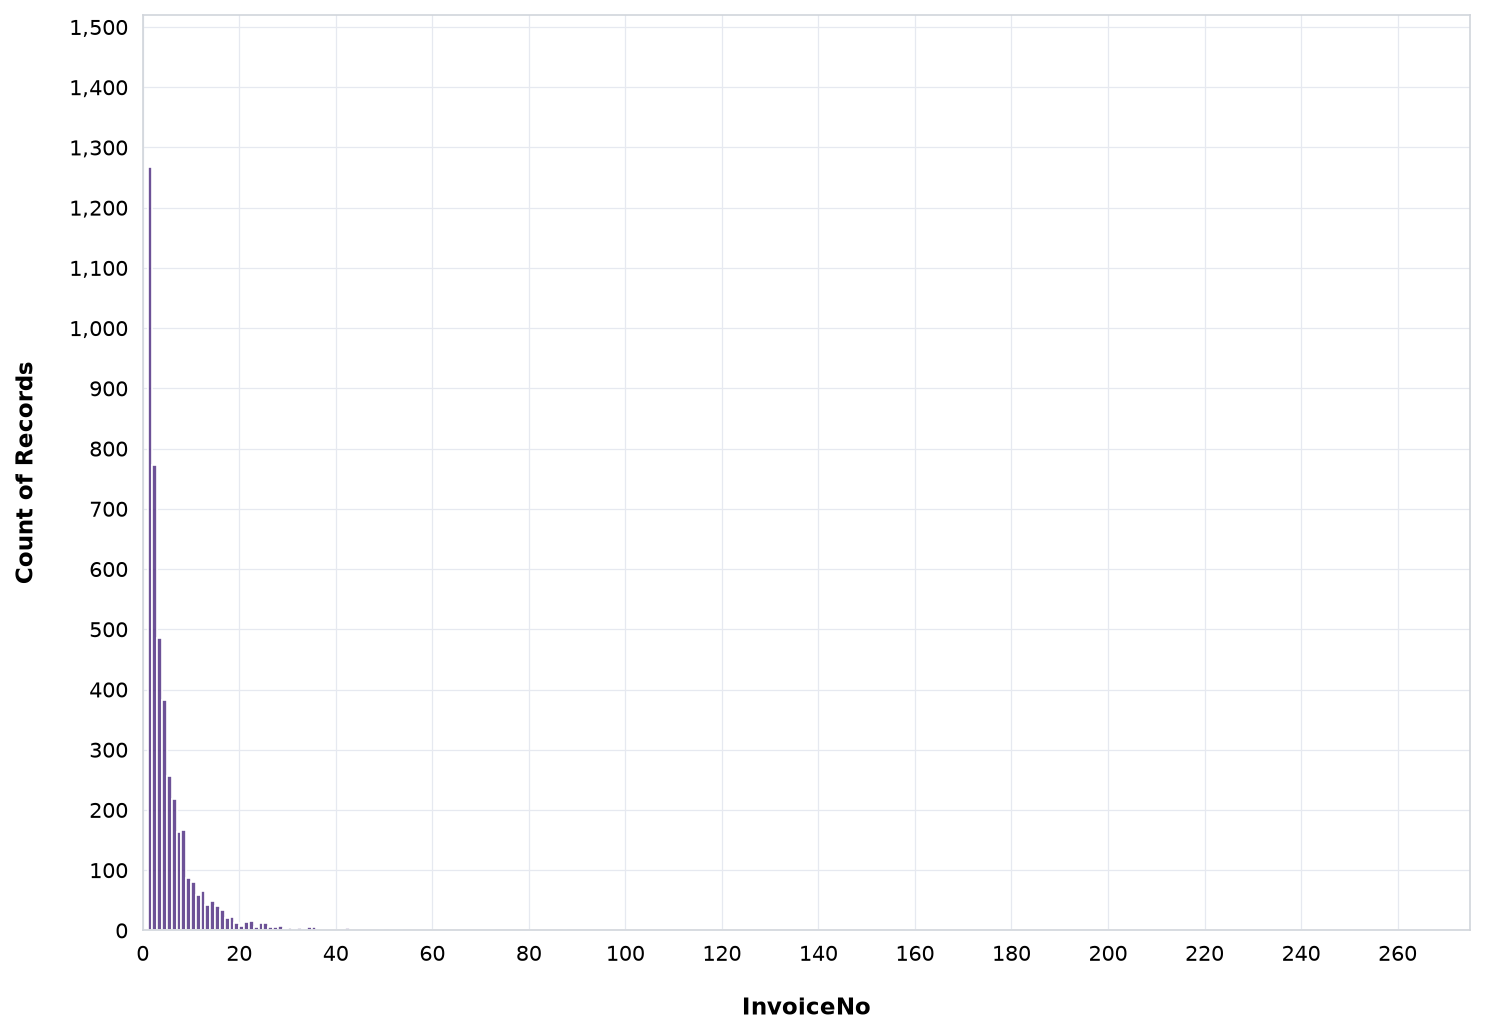

In [9]:
# Here we find that 71.09 % of customers ordered more than once and 53.46 % have ordered more than twice. 
# This is useful to know because it indicates that there will be noticeable retention across cohorts given that the majority of users are placing multiple orders. 
# We can also visualize this using a histogram.

# 1. Подготовка данных: число уникальных заказов (Invoice) на каждого покупателя
n_orders = df2.groupby('CustomerID')['Invoice'].nunique()

# 2. Настройка холста
fig, ax = plt.subplots(figsize=(10, 7), dpi=150)
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# 3. Построение гистограммы
# binwidth=1 делает каждый столбец равным 1 заказу
sns.histplot(
    data=n_orders,
    binwidth=1,
    color='#3C1874',          # Тёмно-фиолетовый цвет как на скриншоте
    edgecolor='white',        # Белая граница между столбиками
    linewidth=0.8,
    ax=ax
)

# 4. Настройка осей и подписей
ax.set_xlabel('InvoiceNo', fontsize=11, fontweight='bold', labelpad=15)
ax.set_ylabel('Count of Records', fontsize=11, fontweight='bold', labelpad=15)

# Лимиты осей (как на образце: от 0 до чуть больше 200 по X, до 1500 по Y)
ax.set_xlim(0, n_orders.max() + 5)
ax.set_ylim(0, 1520)

# Шаг сетки по оси X (каждые 20) и по оси Y (каждые 100)
ax.xaxis.set_major_locator(ticker.MultipleLocator(20))
ax.yaxis.set_major_locator(ticker.MultipleLocator(100))

# Форматирование чисел оси Y через запятую (1,000, 1,100 ...)
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

# 5. Тонкая светлая фоновая сетка
ax.grid(True, linestyle='-', linewidth=0.6, color='#E6E9F0', zorder=0)
ax.set_axisbelow(True)  # Сетка позади столбцов

# 6. Оформление границ графика (рамки)
for spine in ax.spines.values():
    spine.set_color('#D1D5DB')
    spine.set_linewidth(0.8)

# Скрываем засечки на осях
ax.tick_params(left=False, bottom=False, labelsize=10)

plt.tight_layout()
plt.show()

## CREATING COHORTS

In [13]:
# In this case, we're using the month of their first purchase. 
# First, let's reduce our dataset to only include the most relevant columns.

df2 = df2[['CustomerID', 'Invoice', 'InvoiceDate', 'Price']].drop_duplicates()


In [ ]:
# Adding cohort and period columns

#  Indicates the cohort that a customer belongs to based on initial purchase date (using the transform method will return all of the original indices with the applied transformation)

df2['cohort'] = df2.groupby('CustomerID')['InvoiceDate'].transform('min').dt.to_period('M')

# Indicates the month that each customer has made a purchase

df2['order_month'] = df2['InvoiceDate'].dt.to_period('M')

In [22]:
# We can now aggregate the data for each cohort and order_month and count the number of unique customers in each group. 
# Additionally, we add the period_number, which indicates the difference between the cohort date and the month of each individual purchase.

cohorts = df2.groupby(['cohort', 'order_month']).agg(n_customers=('CustomerID', 'nunique'), total_spent=('Price', 'sum')).reset_index(drop=False)

cohorts["period_number"] = (cohorts["order_month"] - cohorts["cohort"]).apply(attrgetter("n"))


#Converts timestamps into calendar dates

cohorts["cohort"] = cohorts["cohort"].apply(lambda row: f"{calendar.month_abbr[int(str(row).split('-')[1])]} {str(row).split('-')[0]}")

cohorts["order_month"] = cohorts["order_month"].apply(lambda row: f"{calendar.month_abbr[int(str(row).split('-')[1])]} {str(row).split('-')[0]}")


In [24]:
cohorts.head(10)

,cohort,order_month,n_customers,total_spent,period_number
0,Dec 2009,Dec 2009,1045,61990.220,0
1,Dec 2009,Jan 2010,392,55953.351,1
2,Dec 2009,Feb 2010,358,24374.502,2
3,Dec 2009,Mar 2010,447,30202.850,3
4,Dec 2009,Apr 2010,410,31301.060,4
5,Dec 2009,May 2010,408,27990.010,5
6,Dec 2009,Jun 2010,408,26289.620,6
7,Dec 2009,Jul 2010,374,28760.260,7
8,Dec 2009,Aug 2010,355,24371.690,8
9,Dec 2009,Sep 2010,392,56114.950,9


In [26]:
# We can now pivot our data to create our retention matrices. 
# A retention matrix will show us how user activity changes over time for each of our cohorts.

retention_relative = cohorts.pivot_table(index='cohort', columns='period_number', values='n_customers', sort=False)

columns = cohorts["order_month"].unique().tolist()

retention_absolute = cohorts.pivot_table(index="cohort", columns="order_month", values="n_customers", sort=False)[columns]

retention_price = cohorts.pivot_table(index="cohort", columns="period_number", values="total_spent", sort=False)


## VISUALIZING COHORTS

In [ ]:
# In this section, we will visualize each retention matrix to get an understanding of the overall retention for each cohort, patterns that may appear, and how each cohort compares to the other cohorts.

# Below we've defined a function that will plot each matrix and format it for the metric we're hoping to understand. 
# Relative retention
# Absolute retention
# Spending retention


# In the table below, we see an average retention of 20.62 in the first period across all cohorts. 
# Also, if you look at the diagonal that represents the month of November 2021, we can see that there seems to be a slight uptick in purchases across cohorts. 
# This could possibly be caused by customers coming back to do some holiday shopping.


def plot_retention(retention_matrix, retention_type='relative'):
    # 1. Размер каждой когорты (столбец period_number = 0)
    cohort_sizes = retention_matrix.iloc[:, 0]
    
    # 2. Если выбран относительный retention — переводим абсолютные числа в доли от 0 до 1
    if retention_type == 'relative':
        matrix_to_plot = retention_matrix.divide(cohort_sizes, axis=0)
        fmt = '.0%'
    else:
        matrix_to_plot = retention_matrix
        fmt = 'g'
        
    # 3. Настройка холста
    fig, ax = plt.subplots(figsize=(14, 9), dpi=150)
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')
    
    # 4. Построение тепловой карты
    # RdYlGn — градиент от красного (низкий retention) к зеленому (высокий retention)
    sns.heatmap(
        matrix_to_plot,
        annot=True,
        fmt=fmt,
        cmap='RdYlGn',
        vmin=0.0,
        vmax=1.0 if retention_type == 'relative' else None,
        cbar=True,
        linewidths=0.5,
        linecolor='white',
        ax=ax,
        mask=matrix_to_plot.isna()  # Скрываем пустые ячейки (NaN)
    )
    
    # 5. Оформление заголовков и осей
    ax.set_title('Monthly Cohorts: Relative User Retention', fontsize=14, pad=15)
    ax.set_xlabel('period since initial purchase', fontsize=10, labelpad=10)
    ax.set_ylabel('cohort', fontsize=10, labelpad=10)
    
    # Форматирование меток строк (например, 'Dec 2020')
    if hasattr(retention_matrix.index, 'strftime'):
        y_labels = [dt.strftime('%b %Y') for dt in retention_matrix.index]
        ax.set_yticklabels(y_labels, rotation=0)
    else:
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

    # 6. Вывод размера когорты (cohort size) слева от меток
    ax.text(-0.8, -0.2, 'cohort size', ha='center', va='center', fontsize=9, transform=ax.get_yaxis_transform())
    for i, size in enumerate(cohort_sizes):
        ax.text(-0.8, i + 0.5, f'{int(size):,}', ha='center', va='center', fontsize=9, transform=ax.get_yaxis_transform())
        
    plt.tight_layout()
    plt.show()



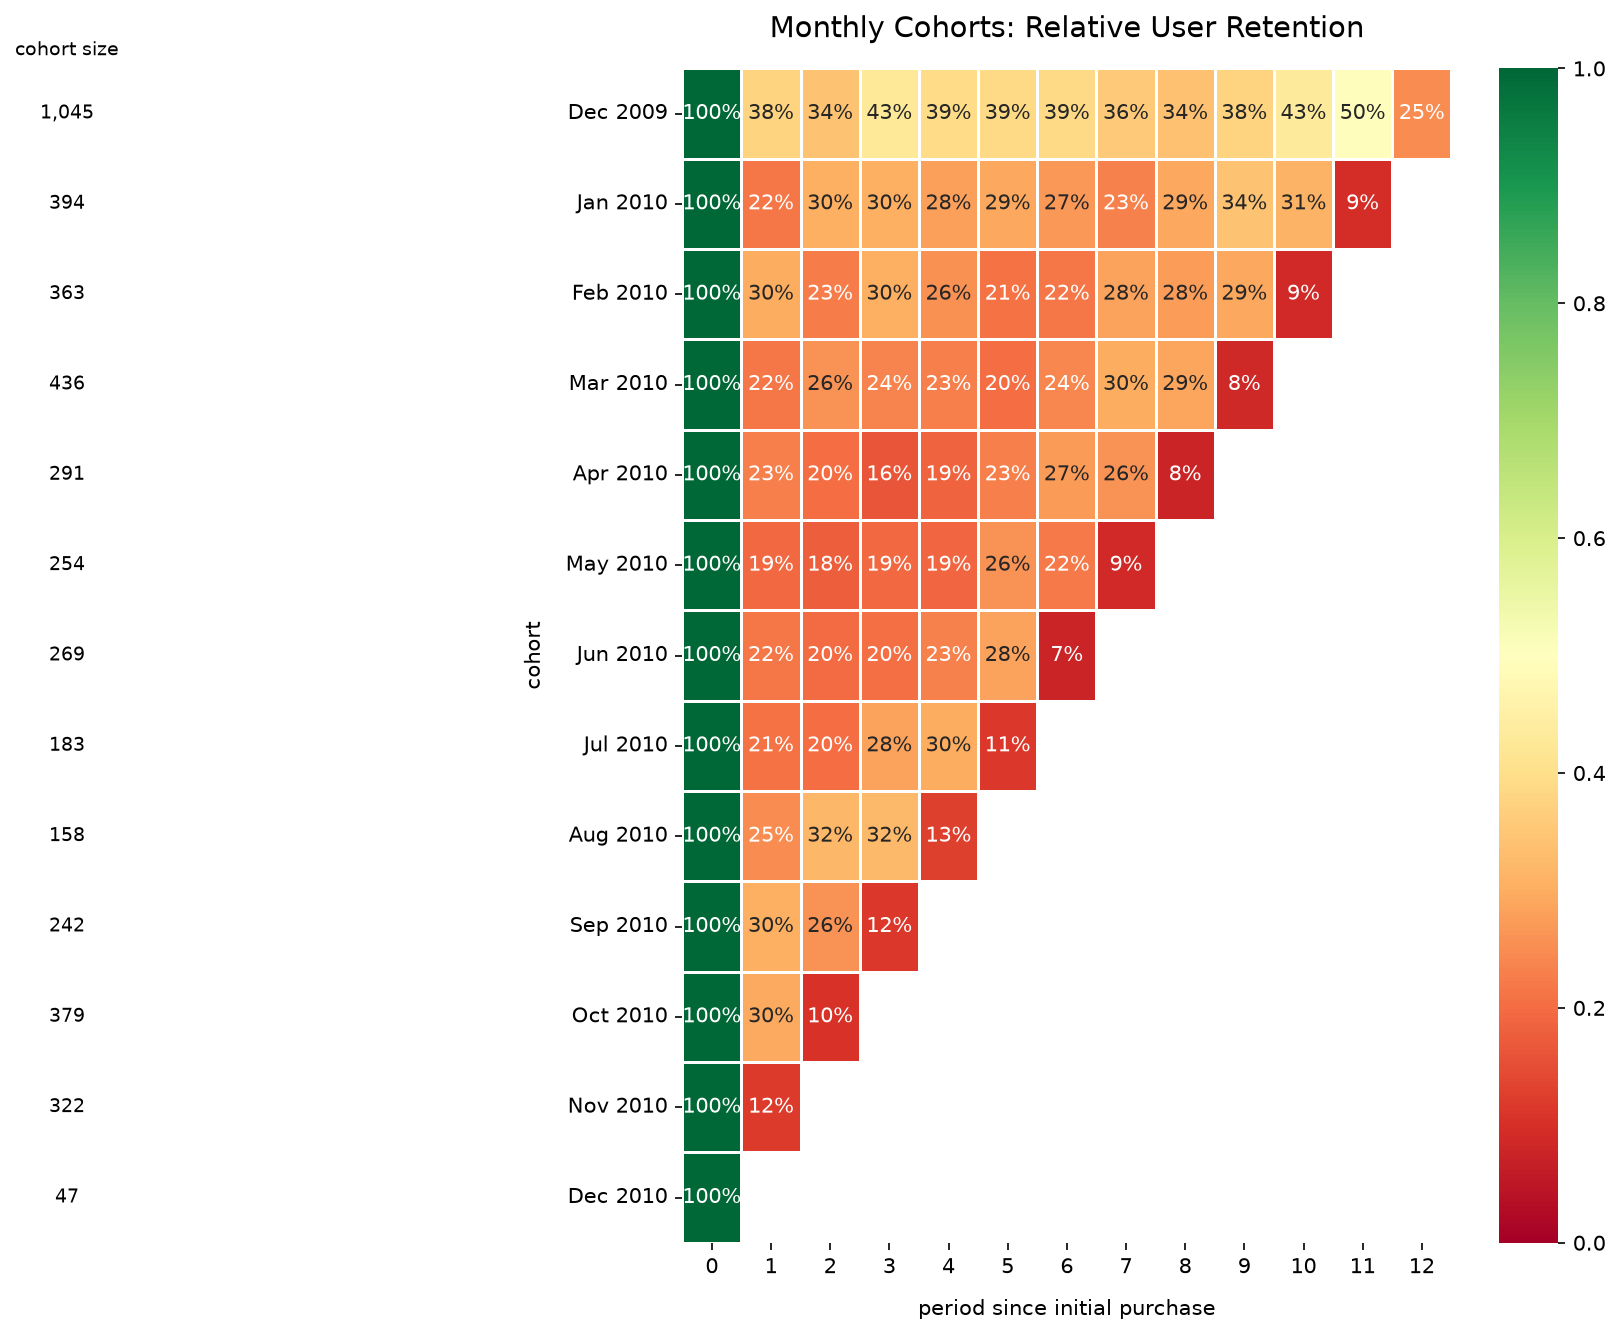

In [29]:
plot_retention(retention_relative, 'relative')

In [ ]:
# The chart below is a slight variation, instead, showing how each cohort stacks up in the same calendar month. 
# In this chart, the columns represent the activity for all cohorts in a given calendar month, which makes it easier to see how a specific time of year may impact the cohort. 
# Only the oldest cohorts will have complete data for all months in this chart, as newer cohorts have not yet made their first purchase in the earliest months. 
# For absolute cohort retention charts, the diagonals give us an idea of cohort activity at the same cohort age. 


def plot_retention(retention_matrix, retention_type='relative'):
    # 1. Извлекаем размер когорты (максимальное число пользователей в строке, то есть в месяц старта)
    cohort_sizes = retention_matrix.max(axis=1)
    
    # 2. Нормализация к долям (0..1) относительно размера когорты
    matrix_to_plot = retention_matrix.divide(cohort_sizes, axis=0)
    
    # 3. Настройка холста
    fig, ax = plt.subplots(figsize=(14, 9), dpi=150)
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')
    
    # 4. Определение заголовка в зависимости от типа
    title = ('Monthly Cohorts: Absolute User Retention' 
             if retention_type == 'absolute' 
             else 'Monthly Cohorts: Relative User Retention')
    
    # 5. Отрисовка тепловой карты
    sns.heatmap(
        matrix_to_plot,
        annot=True,
        fmt='.0%',
        cmap='RdYlGn',
        vmin=0.0,
        vmax=1.0,
        cbar=True,
        linewidths=0.5,
        linecolor='white',
        ax=ax,
        mask=matrix_to_plot.isna()  # Скрывает пустые ячейки (NaN)
    )
    
    # 6. Заголовки и подписи
    ax.set_title(title, fontsize=14, pad=15)
    ax.set_ylabel('cohort', fontsize=10, labelpad=10)
    
    if retention_type == 'relative':
        ax.set_xlabel('period since initial purchase', fontsize=10, labelpad=10)
    else:
        ax.set_xlabel('', fontsize=0)
        
    # Форматирование подписей строк (Dec 2020, Jan 2021 ...)
    if hasattr(retention_matrix.index, 'strftime'):
        y_labels = [dt.strftime('%b %Y') for dt in retention_matrix.index]
        ax.set_yticklabels(y_labels, rotation=0)
    else:
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
        
    # Форматирование подписей колонок для абсолютной матрицы (Dec 2020, Jan 2021 ...)
    if retention_type == 'absolute':
        if hasattr(retention_matrix.columns, 'strftime'):
            x_labels = [dt.strftime('%b %Y') for dt in retention_matrix.columns]
            ax.set_xticklabels(x_labels, rotation=90)
        else:
            ax.set_xticklabels(ax.get_xticklabels(), rotation=90)

    # 7. Добавление колонки cohort size слева
    ax.text(-0.8, -0.2, 'cohort size', ha='center', va='center', fontsize=9, transform=ax.get_yaxis_transform())
    for i, size in enumerate(cohort_sizes):
        ax.text(-0.8, i + 0.5, f'{int(size):,}', ha='center', va='center', fontsize=9, transform=ax.get_yaxis_transform())
        
    plt.tight_layout()
    plt.show()

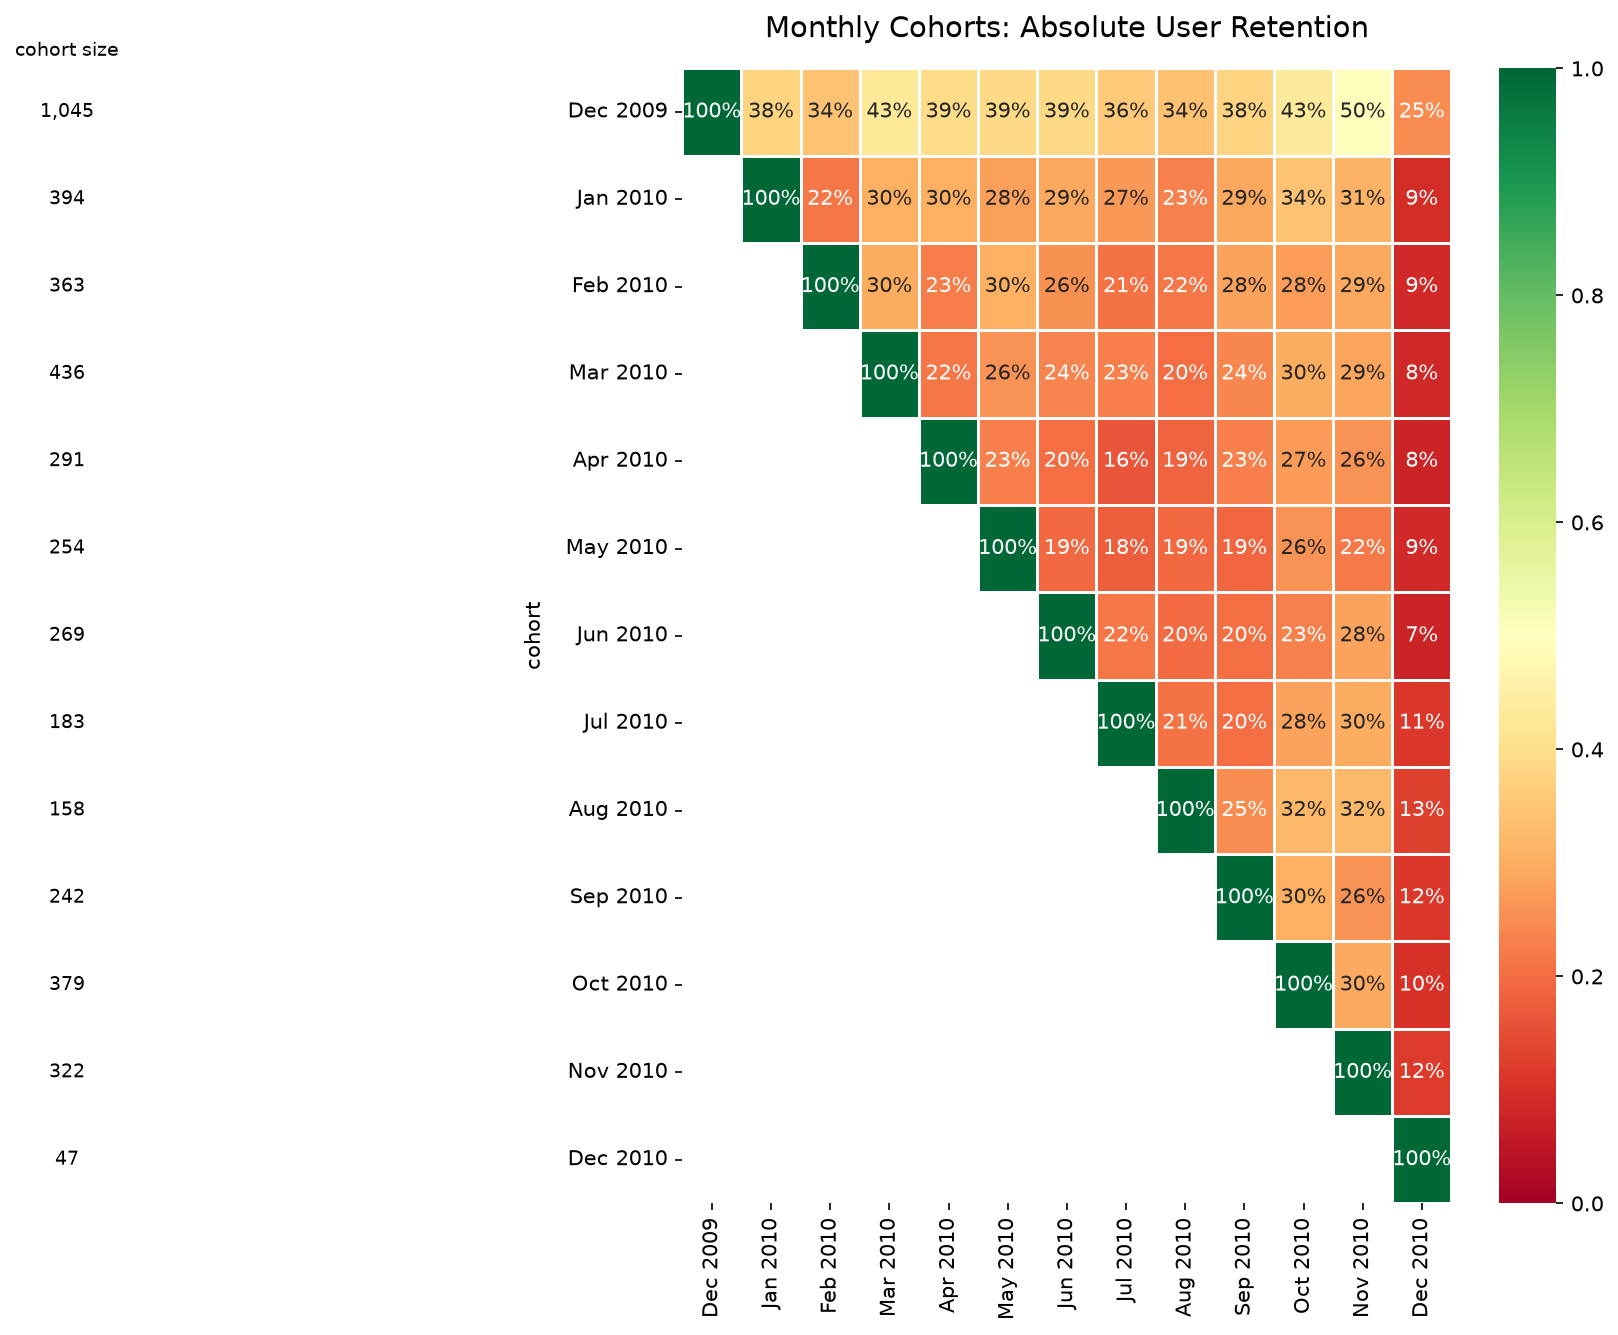

In [31]:
plot_retention(retention_absolute, 'absolute')


In [ ]:
# The final chart (below) shows us the spending patterns of each cohort. 
# It looks at the total amount each cohort spent during the month of their initial purchase and how much they spend in the following months in comparison. 
# Notice how the August cohort spent 80% of their initial period in October and 101% in November 🤯 . 
# Something about this cohort is especially driven to return to your store for some early fall holiday shopping. 
# You might want to dig into what makes this cohort so special as a following! 


def plot_retention(retention_matrix, retention_type='relative'):
    # 1. Расчет базовых значений для нормировки строки
    if retention_type == 'absolute':
        base_values = retention_matrix.max(axis=1)
    else:
        # Для 'relative' и 'price' первый столбец — период 0
        base_values = retention_matrix.iloc[:, 0]
        
    # 2. Нормализация к долям (относительно периода 0)
    matrix_to_plot = retention_matrix.divide(base_values, axis=0)
    
    # 3. Настройка холста
    fig, ax = plt.subplots(figsize=(14, 9), dpi=150)
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')
    
    # 4. Построение тепловой карты
    sns.heatmap(
        matrix_to_plot,
        annot=True,
        fmt='.0%',
        cmap='RdYlGn',
        vmin=0.0,
        vmax=1.0,
        cbar=True,
        linewidths=0.5,
        linecolor='white',
        ax=ax,
        mask=matrix_to_plot.isna()  # Скрываем не наступившие периоды
    )
    
    # 5. Подписи осей и заголовки в зависимости от типа матрицы
    ax.set_ylabel('cohort', fontsize=10, labelpad=10)
    
    if retention_type == 'price':
        # Для price заголовок сверху отсутствует, ось X называется period_number
        ax.set_xlabel('period_number', fontsize=10, labelpad=10)
    elif retention_type == 'relative':
        ax.set_title('Monthly Cohorts: Relative User Retention', fontsize=14, pad=15)
        ax.set_xlabel('period since initial purchase', fontsize=10, labelpad=10)
    elif retention_type == 'absolute':
        ax.set_title('Monthly Cohorts: Absolute User Retention', fontsize=14, pad=15)
        ax.set_xlabel('', fontsize=0)

    # Форматирование подписей строк (Dec 2020, Jan 2021...)
    if hasattr(retention_matrix.index, 'strftime'):
        y_labels = [dt.strftime('%b %Y') for dt in retention_matrix.index]
        ax.set_yticklabels(y_labels, rotation=0)
    else:
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

    # Форматирование подписей столбцов для absolute (даты)
    if retention_type == 'absolute':
        if hasattr(retention_matrix.columns, 'strftime'):
            x_labels = [dt.strftime('%b %Y') for dt in retention_matrix.columns]
            ax.set_xticklabels(x_labels, rotation=90)
        else:
            ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
            
    # 6. Блок cohort size слева (только для relative и absolute)
    if retention_type in ['relative', 'absolute']:
        ax.text(-0.8, -0.2, 'cohort size', ha='center', va='center', fontsize=9, transform=ax.get_yaxis_transform())
        for i, size in enumerate(base_values):
            ax.text(-0.8, i + 0.5, f'{int(size):,}', ha='center', va='center', fontsize=9, transform=ax.get_yaxis_transform())

    plt.tight_layout()
    plt.show()

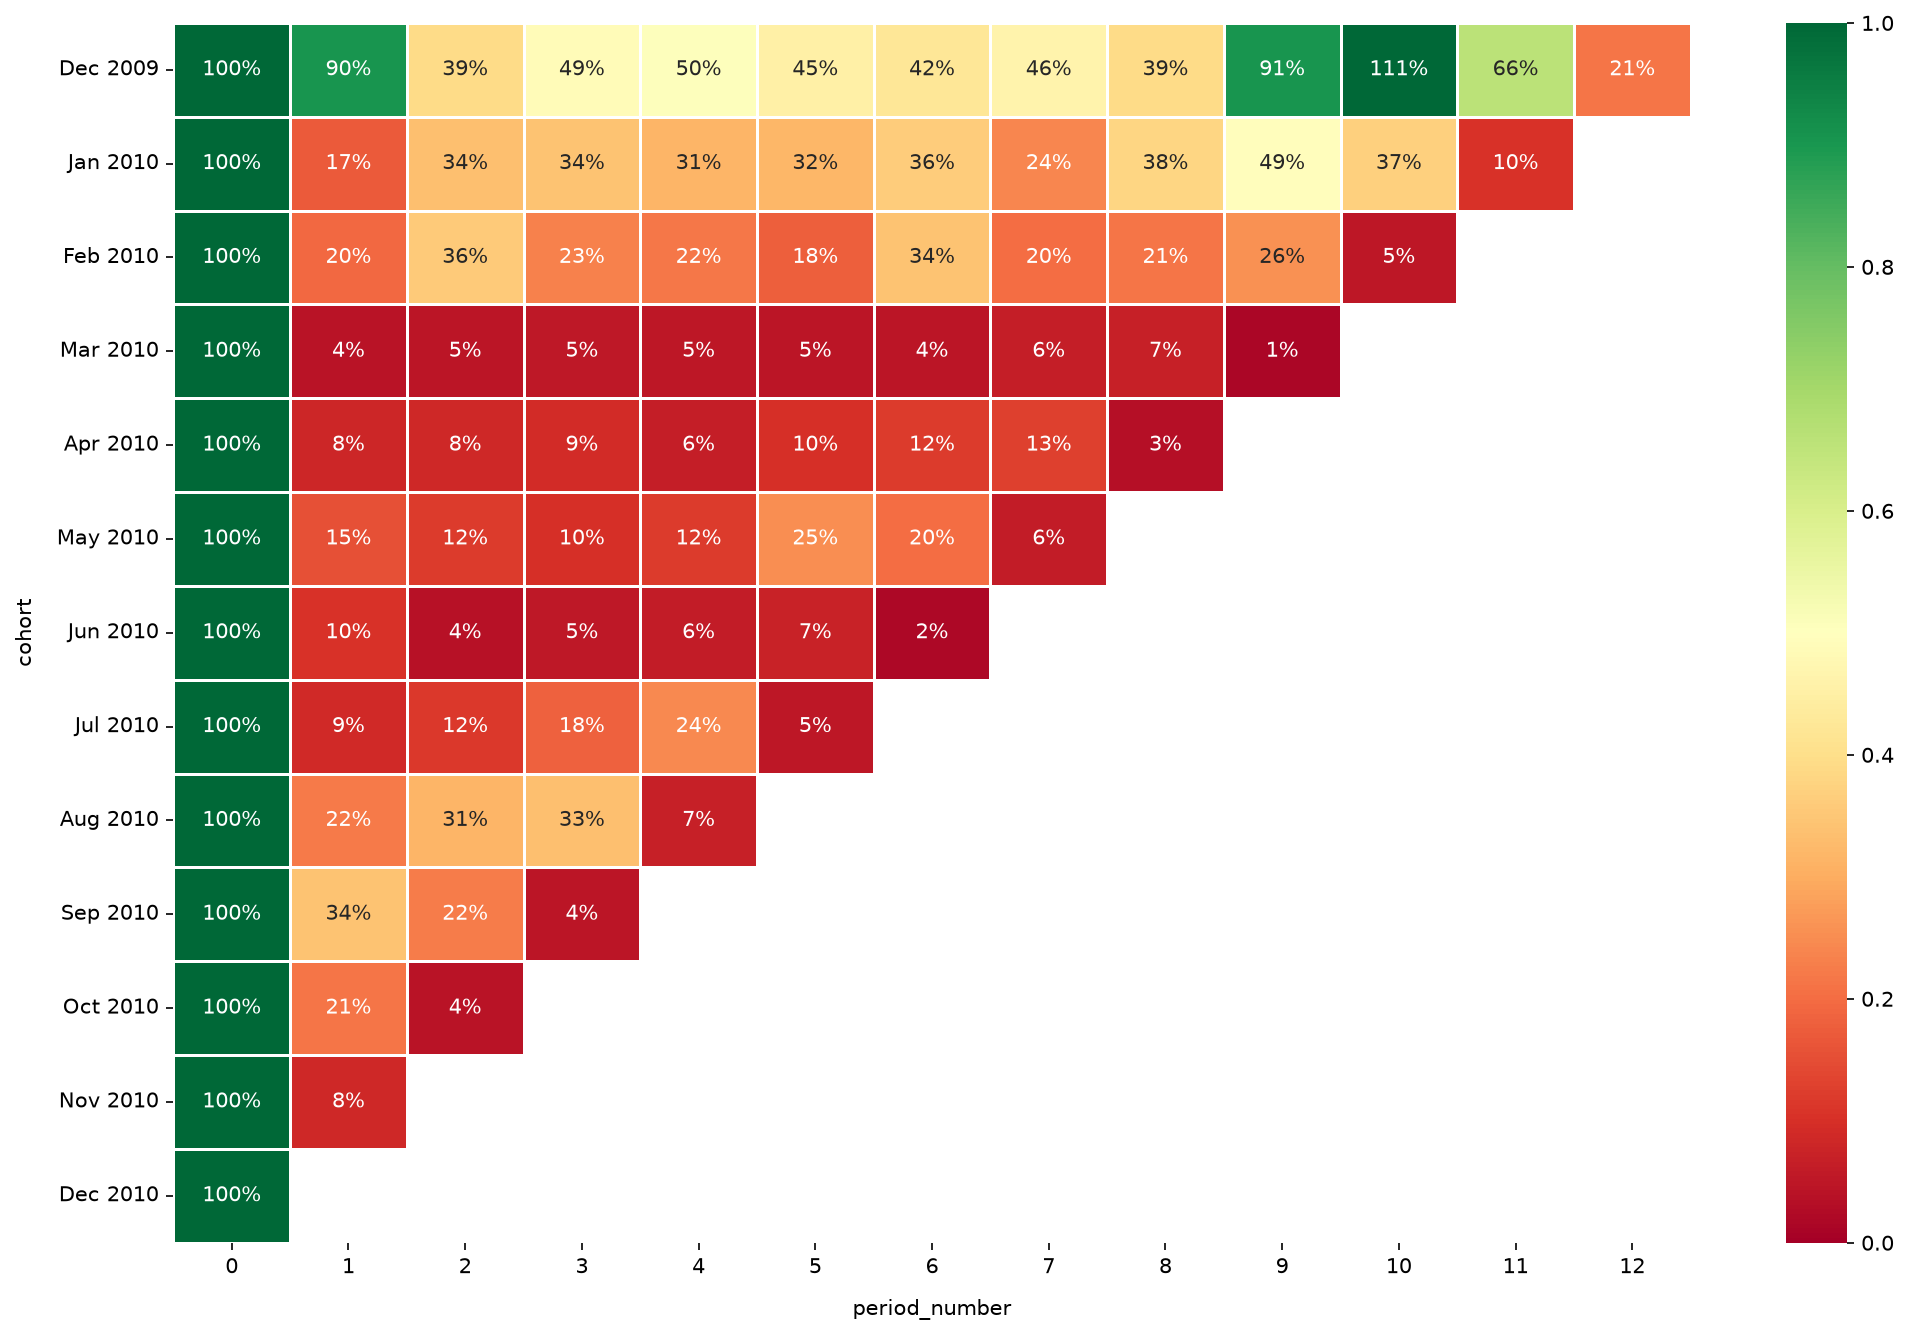

In [33]:
plot_retention(retention_price, 'price')

In [34]:
# Next, we can visualize the activity of each cohort using line charts to get an alternate view of how the retention of one cohort compares to the others. 
# Notice how there's a significant gap between the December cohort and all other cohorts. 
# This shows that customers in the December cohort are retained at a much higher rate than any other cohort!


# 1. Нормализуем retention_relative: делим каждую строку на стартовый размер (колонка 0)
cohort_sizes = retention_relative.iloc[:, 0]
retention_rate = retention_relative.divide(cohort_sizes, axis=0)

# 2. Переводим матрицу из широкого формата в длинный (long format) для Plotly
df_plot = retention_rate.reset_index().melt(
    id_vars='cohort',
    var_name='period_number',
    value_name='retention'
).dropna()

# Форматируем название когорты в красивую строку, если это Period/Timestamp ('Apr 2021')
if hasattr(df_plot['cohort'].iloc[0], 'strftime'):
    df_plot['cohort'] = df_plot['cohort'].apply(lambda x: x.strftime('%b %Y'))
else:
    df_plot['cohort'] = df_plot['cohort'].astype(str)

# Гарантируем числовой тип шага периода
df_plot['period_number'] = df_plot['period_number'].astype(int)

# 3. Построение линейного графика со сглаживанием (spline) и маркерами
fig = px.line(
    df_plot,
    x='period_number',
    y='retention',
    color='cohort',
    markers=True,
    labels={
        'period_number': 'period_number',
        'retention': 'Percentage of users',
        'cohort': 'cohort'
    }
)

# 4. Включаем сглаживание линий (spline) и настраиваем толщину как на скриншоте
fig.update_traces(
    line_shape='spline',
    line_width=2.5,
    marker=dict(size=6)
)

# 5. Выделяем когорту Dec 2020 толстой контрастной линией (акцент графика)
for trace in fig.data:
    if trace.name == 'Dec 2020':
        trace.line.width = 3.5
        trace.line.color = '#E24A4A'  # Выразительный кораллово-красный цвет

# 6. Оформление осей, сетки и фона
fig.update_layout(
    plot_bgcolor='white',
    paper_bgcolor='white',
    width=1000,
    height=680,
    xaxis=dict(
        showgrid=True,
        gridcolor='#F0F2F5',
        zeroline=False,
        dtick=1,
        range=[-0.2, 12.2],
        title_font=dict(size=12, color='black'),
        tickfont=dict(size=11, color='black')
    ),
    yaxis=dict(
        showgrid=True,
        gridcolor='#F0F2F5',
        zeroline=False,
        dtick=0.1,
        range=[-0.02, 1.02],
        tickformat='.1f',
        title_font=dict(size=12, color='black'),
        tickfont=dict(size=11, color='black')
    ),
    legend=dict(
        title_text='<b>cohort</b>',
        title_font=dict(size=12),
        font=dict(size=11),
        y=1,
        x=1.02,
        orientation='v'
    ),
    hovermode='closest'
)

fig.show()